In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import joblib

In [13]:
daily = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\daily_covers.xlsx")
res = pd.read_excel(r"C:\Users\soumy\Downloads\Aurika\data\reservations.xlsx")

daily['date'] = pd.to_datetime(daily['date'])
res['date'] = pd.to_datetime(res['date'])
res['booked_at'] = pd.to_datetime(res['booked_at'], errors='coerce')

In [14]:
# Daily
daily = daily[daily['is_complete'] == True]
daily = daily[(daily['avg_check'] > 0) & (daily['covers_count'] > 0)]
daily = daily[daily['anomaly_flag'].isna()]
daily = daily[daily['notes'] != 'buyout']

# Reservations
res = res[res['status'].isin(['confirmed', 'no_show'])]

res['lead_time'] = (res['date'] - res['booked_at']).dt.days
res['lead_time'] = res['lead_time'].fillna(0)

res['arrival_time'] = res['arrival_time'].fillna("unknown")

In [15]:
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['weekend'] = daily['day_of_week'].isin([5,6]).astype(int)

In [16]:
res_daily = res.groupby('date').agg({
    'party_size': 'sum',
    'reservation_id': 'count',
    'is_vip': 'sum',
    'lead_time': 'mean'
}).reset_index()

res_daily.columns = [
    'date',
    'total_party',
    'total_reservations',
    'vip_count',
    'avg_lead_time'
]

In [17]:
df = pd.merge(daily, res_daily, on='date', how='left')

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

df = df.sort_values('date')

In [18]:
# Lag
df['lag_7'] = df['covers_count'].shift(7)
df['lag_14'] = df['covers_count'].shift(14)

# Rolling
df['rolling_mean_7'] = df['covers_count'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['covers_count'].shift(1).rolling(7).std()

# Ratios
df['reservation_per_person'] = df['total_reservations'] / (df['total_party'] + 1)
df['vip_ratio'] = df['vip_count'] / (df['total_reservations'] + 1)

# SAFE NaN handling (IMPORTANT FIX)
df = df.dropna(subset=['lag_7', 'lag_14', 'rolling_mean_7'])

df = df.fillna(0)

In [19]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train:", len(train), "Test:", len(test))

Train: 474 Test: 119


In [20]:
features = [
    'day_of_week', 'month', 'weekend',
    'total_party', 'total_reservations',
    'vip_count', 'avg_lead_time',
    'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'reservation_per_person', 'vip_ratio'
]

X_train = train[features]
X_test = test[features]

MODEL 1 - covers

In [21]:
y_train = train['covers_count']
y_test = test['covers_count']

model = XGBRegressor(n_estimators=200, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)
bias = np.sum(y_pred - y_test) / np.sum(y_test)

print("COVERS MODEL")
print("MAE:", mae)
print("wMAPE:", wmape)
print("Bias:", bias)

COVERS MODEL
MAE: 10.713436126708984
wMAPE: 0.06204491671546786
Bias: -0.016958411946147244


In [23]:
baseline = df.groupby('day_of_week')['covers_count'].mean()
test['baseline_pred'] = test['day_of_week'].map(baseline)

baseline_mae = mean_absolute_error(y_test, test['baseline_pred'])

print("Baseline MAE:", baseline_mae)
print("Model MAE:", mae)

Baseline MAE: 18.392553352193836
Model MAE: 10.713436126708984


MODEL 2 - avg_check

In [24]:
y_train_check = train['avg_check']
y_test_check = test['avg_check']

model_check = XGBRegressor(n_estimators=200, max_depth=5)
model_check.fit(X_train, y_train_check)

y_pred_check = model_check.predict(X_test)

In [25]:
mae_check = mean_absolute_error(y_test_check, y_pred_check)
wmape_check = np.sum(np.abs(y_test_check - y_pred_check)) / np.sum(y_test_check)
bias_check = np.sum(y_pred_check - y_test_check) / np.sum(y_test_check)

print("AVG_CHECK MODEL")
print("MAE:", mae_check)
print("wMAPE:", wmape_check)
print("Bias:", bias_check)

AVG_CHECK MODEL
MAE: 6.031114545549665
wMAPE: 0.07228260217626638
Bias: 0.007612919080156944


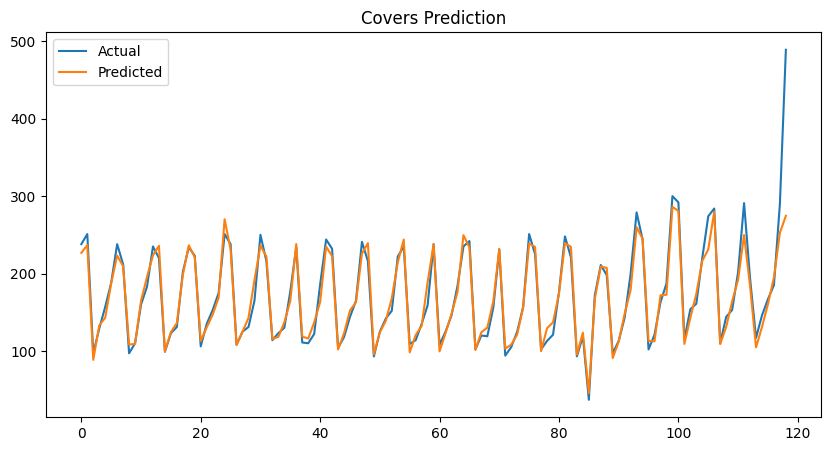

In [26]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Covers Prediction")
plt.show()

In [27]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                   feature  importance
4       total_reservations    0.824610
3              total_party    0.131411
0              day_of_week    0.021224
1                    month    0.005312
9           rolling_mean_7    0.003226
7                    lag_7    0.002858
5                vip_count    0.002217
8                   lag_14    0.002183
11  reservation_per_person    0.002132
10           rolling_std_7    0.002019
6            avg_lead_time    0.001621
12               vip_ratio    0.001187
2                  weekend    0.000000


In [28]:
joblib.dump(model, "covers_model.pkl")
joblib.dump(model_check, "avg_check_model.pkl")

['avg_check_model.pkl']